In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
os.makedirs('../output', exist_ok=True)
os.makedirs('../scripts', exist_ok=True)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(r"C:\Users\dawes\OneDrive\Desktop\Ecommerce-Return-Rate-Analysis\data\returns_sustainability_dataset.csv")
df['Order_Date']    = pd.to_datetime(df['Order_Date'])
df['Order_Year']    = df['Order_Date'].dt.year
df['Order_Month']   = df['Order_Date'].dt.month
df['Return_Binary'] = (df['Return_Status'] == 'Returned').astype(int)

print("✅ Data loaded!")
print("Shape:", df.shape)
print("\nTarget Distribution:")
print(df['Return_Binary'].value_counts())
print(f"\nReturn Rate: {df['Return_Binary'].mean()*100:.1f}%")

✅ Data loaded!
Shape: (5000, 26)

Target Distribution:
Return_Binary
0    3550
1    1450
Name: count, dtype: int64

Return Rate: 29.0%


In [5]:
# ============================================================
# FEATURE SELECTION
# ============================================================

features = [
    'Product_Category',
    'Product_Price',
    'Order_Quantity',
    'Discount_Applied',
    'Shipping_Method',
    'Payment_Method',
    'User_Age',
    'User_Gender',
    'Order_Year',
    'Order_Month',
    'Order_Value',
]

target = 'Return_Binary'
df_ml  = df[features + [target]].copy()

print("✅ Features selected!")
print(f"\nTotal Features : {len(features)}")
print(f"Categorical    : Product_Category, Shipping_Method, Payment_Method, User_Gender")
print(f"Numeric        : Product_Price, Order_Quantity, Discount_Applied,")
print(f"                 User_Age, Order_Year, Order_Month, Order_Value")
print(f"\nTarget         : Return_Binary (0 = Not Returned, 1 = Returned)")
df_ml.head(3)

✅ Features selected!

Total Features : 11
Categorical    : Product_Category, Shipping_Method, Payment_Method, User_Gender
Numeric        : Product_Price, Order_Quantity, Discount_Applied,
                 User_Age, Order_Year, Order_Month, Order_Value

Target         : Return_Binary (0 = Not Returned, 1 = Returned)


,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,User_Age,User_Gender,Order_Year,Order_Month,Order_Value,Return_Binary
0,Clothing,1720.71,2,30.46,Next-Day,Wallet,57,Female,2022,1,2393.163468,0
1,Toys,744.06,5,29.62,Next-Day,Wallet,55,Female,2022,1,2618.347140,1
2,Clothing,983.68,5,47.80,Express,Wallet,37,Female,2025,3,2567.404800,0


In [6]:
# ============================================================
# ENCODE CATEGORICAL COLUMNS
# ============================================================

categorical_cols = [
    'Product_Category',
    'Shipping_Method',
    'Payment_Method',
    'User_Gender'
]

df_encoded = df_ml.copy()

# Store encoders for Streamlit
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col]   = le.classes_.tolist()
    print(f"✅ {col} encoded → classes: {le.classes_.tolist()}")

print("\nEncoded DataFrame sample:")
df_encoded.head(3)

✅ Product_Category encoded → classes: ['Books', 'Clothing', 'Electronics', 'Home Appliances', 'Toys']
✅ Shipping_Method encoded → classes: ['Express', 'Next-Day', 'Standard']
✅ Payment_Method encoded → classes: ['COD', 'Credit Card', 'Debit Card', 'Wallet']
✅ User_Gender encoded → classes: ['Female', 'Male']

Encoded DataFrame sample:


,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,User_Age,User_Gender,Order_Year,Order_Month,Order_Value,Return_Binary
0,1,1720.71,2,30.46,1,3,57,0,2022,1,2393.163468,0
1,4,744.06,5,29.62,1,3,55,0,2022,1,2618.347140,1
2,1,983.68,5,47.80,0,3,37,0,2025,3,2567.404800,0


In [7]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X = df_encoded[features]
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Data split complete!")
print(f"\nTotal Samples  : {len(X)}")
print(f"Training Set   : {len(X_train)} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing Set    : {len(X_test)} rows  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nTrain Return Rate : {y_train.mean()*100:.1f}%")
print(f"Test  Return Rate : {y_test.mean()*100:.1f}%")

✅ Data split complete!

Total Samples  : 5000
Training Set   : 4000 rows (80%)
Testing Set    : 1000 rows  (20%)

Train Return Rate : 29.0%
Test  Return Rate : 29.0%


In [8]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling done!")
print("StandardScaler applied — mean=0, std=1 for all numeric features")

✅ Scaling done!
StandardScaler applied — mean=0, std=1 for all numeric features


In [9]:
# ============================================================
# TRAIN MODEL V1 — LOGISTIC REGRESSION
# ============================================================

model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)
model.fit(X_train_scaled, y_train)

y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
acc          = accuracy_score(y_test, y_pred)
auc          = roc_auc_score(y_test, y_pred_proba)

print("✅ Model V1 trained!")
print(f"\nAccuracy : {acc*100:.2f}%")
print(f"ROC-AUC  : {auc:.4f}")

✅ Model V1 trained!

Accuracy : 71.00%
ROC-AUC  : 0.5677


In [10]:
# ============================================================
# TRAIN MODEL V2 — BALANCED (IMPROVED)
# ============================================================

model_v2 = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced'
)
model_v2.fit(X_train_scaled, y_train)

y_pred_v2       = model_v2.predict(X_test_scaled)
y_pred_proba_v2 = model_v2.predict_proba(X_test_scaled)[:, 1]
acc_v2          = accuracy_score(y_test, y_pred_v2)
auc_v2          = roc_auc_score(y_test, y_pred_proba_v2)

print("=" * 50)
print("   MODEL COMPARISON")
print("=" * 50)
print(f"  {'Metric':<20} {'V1':>8} {'V2 (Balanced)':>15}")
print(f"  {'-'*43}")
print(f"  {'Accuracy':<20} {acc*100:>7.2f}% {acc_v2*100:>14.2f}%")
print(f"  {'ROC-AUC':<20} {auc:>8.4f} {auc_v2:>15.4f}")
print("=" * 50)
print("\nClassification Report (V2):")
print(classification_report(y_test, y_pred_v2,
      target_names=['Not Returned', 'Returned']))

   MODEL COMPARISON
  Metric                     V1   V2 (Balanced)
  -------------------------------------------
  Accuracy               71.00%          55.20%
  ROC-AUC                0.5677          0.5682

Classification Report (V2):
              precision    recall  f1-score   support

Not Returned       0.75      0.55      0.64       710
    Returned       0.34      0.56      0.42       290

    accuracy                           0.55      1000
   macro avg       0.54      0.55      0.53      1000
weighted avg       0.63      0.55      0.57      1000



In [11]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

if auc_v2 > auc:
    best_model      = model_v2
    best_pred       = y_pred_v2
    best_pred_proba = y_pred_proba_v2
    best_acc        = acc_v2
    best_auc        = auc_v2
    print("✅ Using V2 (Balanced) model — better AUC")
else:
    best_model      = model
    best_pred       = y_pred
    best_pred_proba = y_pred_proba
    best_acc        = acc
    best_auc        = auc
    print("✅ Using V1 model — already best")

print(f"\nBest Accuracy : {best_acc*100:.2f}%")
print(f"Best AUC      : {best_auc:.4f}")

✅ Using V2 (Balanced) model — better AUC

Best Accuracy : 55.20%
Best AUC      : 0.5682


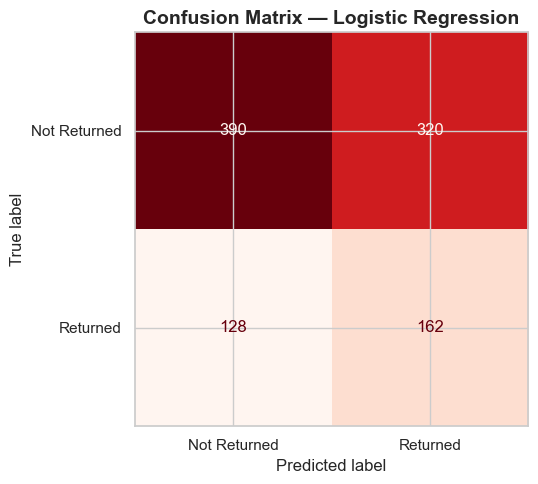

✅ Saved → output/ml_plot1_confusion_matrix.png


In [12]:
# ============================================================
# PLOT 1 — CONFUSION MATRIX
# ============================================================

cm   = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Returned', 'Returned'])
disp.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Confusion Matrix — Logistic Regression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/ml_plot1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → output/ml_plot1_confusion_matrix.png")

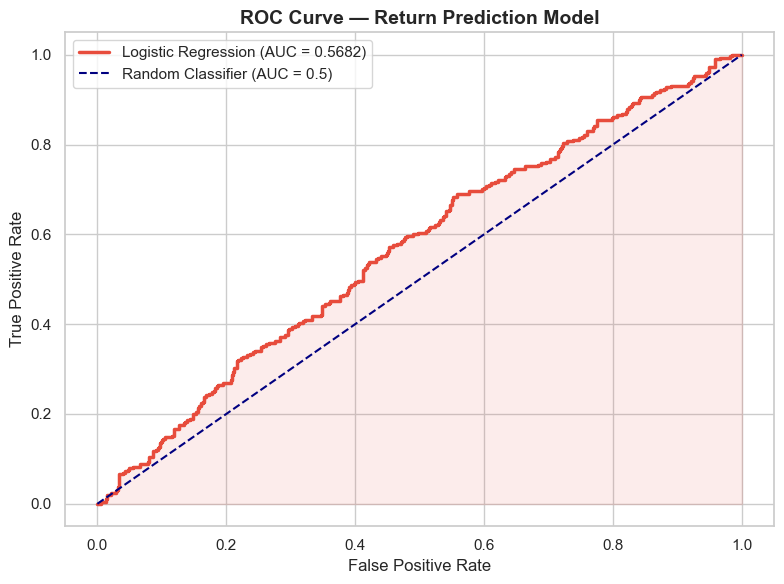

✅ Saved → output/ml_plot2_roc_curve.png


In [13]:
# ============================================================
# PLOT 2 — ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(y_test, best_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
        label=f'Logistic Regression (AUC = {best_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', linestyle='--',
        linewidth=1.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Return Prediction Model',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../output/ml_plot2_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → output/ml_plot2_roc_curve.png")

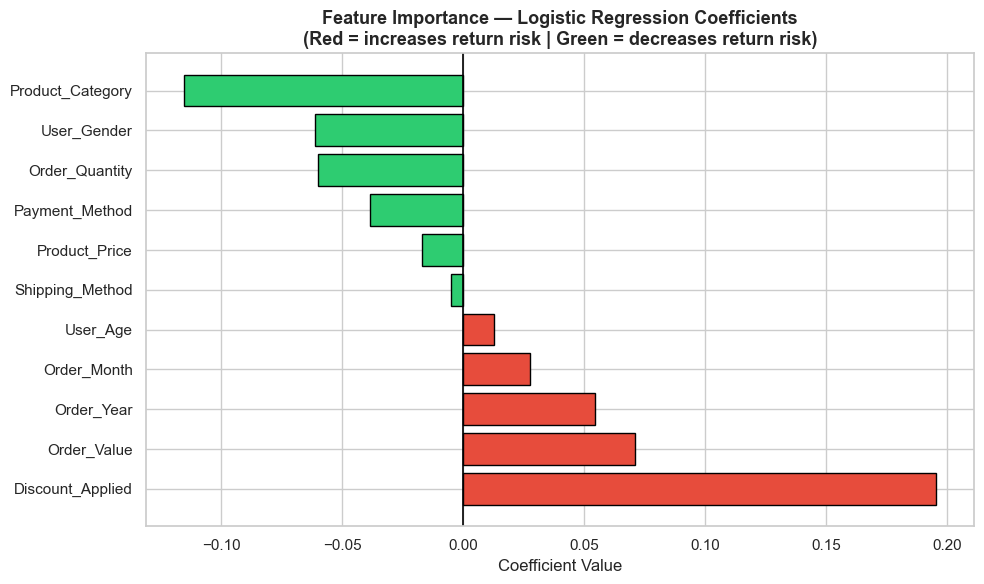

✅ Saved → output/ml_plot3_feature_importance.png


In [14]:
# ============================================================
# PLOT 3 — FEATURE IMPORTANCE
# ============================================================

coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

colors_coef = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=colors_coef, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=1.2)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Feature Importance — Logistic Regression Coefficients\n'
             '(Red = increases return risk | Green = decreases return risk)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/ml_plot3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → output/ml_plot3_feature_importance.png")

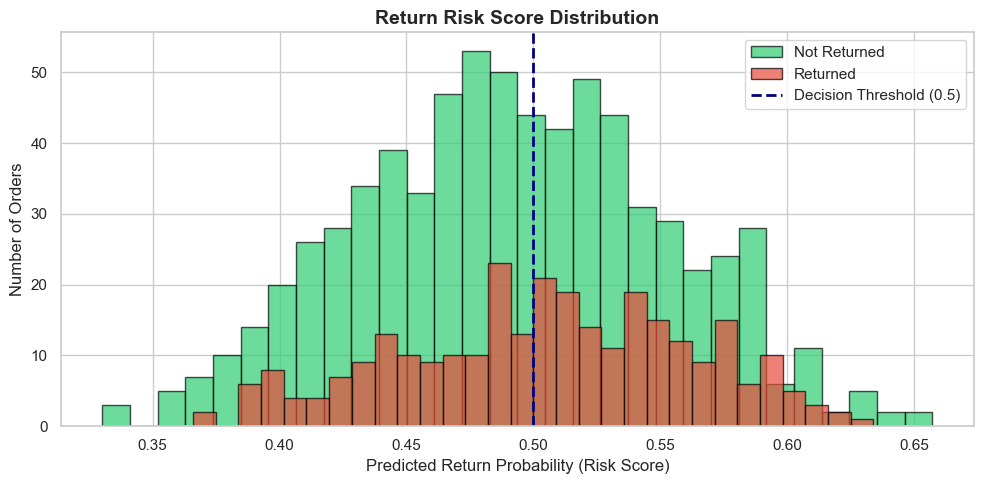

✅ Saved → output/ml_plot4_risk_score_distribution.png


In [15]:
# ============================================================
# PLOT 4 — RISK SCORE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(best_pred_proba[y_test == 0], bins=30, alpha=0.7,
        color='#2ecc71', label='Not Returned', edgecolor='black')
ax.hist(best_pred_proba[y_test == 1], bins=30, alpha=0.7,
        color='#e74c3c', label='Returned', edgecolor='black')
ax.axvline(x=0.5, color='navy', linestyle='--',
           linewidth=2, label='Decision Threshold (0.5)')
ax.set_xlabel('Predicted Return Probability (Risk Score)', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Return Risk Score Distribution',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../output/ml_plot4_risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → output/ml_plot4_risk_score_distribution.png")

In [16]:
# ============================================================
# GENERATE RISK SCORES + EXPORT CSVs
# ============================================================

X_full_scaled = scaler.transform(df_encoded[features])

df['Return_Risk_Score'] = best_model.predict_proba(X_full_scaled)[:, 1]
df['Risk_Label'] = pd.cut(
    df['Return_Risk_Score'],
    bins=[0, 0.40, 0.50, 0.57, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("✅ Risk scores generated for all 5000 orders!")
print("\nRisk Label Distribution:")
print(df['Risk_Label'].value_counts())
print(f"\nMin Score  : {df['Return_Risk_Score'].min():.4f}")
print(f"Max Score  : {df['Return_Risk_Score'].max():.4f}")
print(f"Mean Score : {df['Return_Risk_Score'].mean():.4f}")

scored_df = df[[
    'Order_ID', 'Product_ID', 'Product_Category',
    'Product_Price', 'Discount_Applied', 'Shipping_Method',
    'Payment_Method', 'User_Location', 'Return_Status',
    'Return_Risk_Score', 'Risk_Label',
    'Return_Cost', 'Profit_Loss',
    'Order_Year', 'Order_Month',
    'User_Age', 'User_Gender',
    'Return_Reason'
]].copy()

scored_df['Return_Risk_Score'] = scored_df['Return_Risk_Score'].round(4)
scored_df.to_csv('../output/all_orders_with_risk_scores.csv', index=False)
print("\n✅ Saved → output/all_orders_with_risk_scores.csv")

high_risk_orders = (scored_df[scored_df['Return_Risk_Score'] >= 0.50]
                    .sort_values('Return_Risk_Score', ascending=False)
                    .reset_index(drop=True))
high_risk_orders.to_csv('../output/high_risk_orders.csv', index=False)
print(f"✅ Saved → output/high_risk_orders.csv")
print(f"\nHigh Risk Orders : {len(high_risk_orders)} out of 5000")

✅ Risk scores generated for all 5000 orders!

Risk Label Distribution:
Risk_Label
Medium       2327
High         1831
Very High     575
Low           267
Name: count, dtype: int64

Min Score  : 0.3222
Max Score  : 0.6573
Mean Score : 0.4969

✅ Saved → output/all_orders_with_risk_scores.csv
✅ Saved → output/high_risk_orders.csv

High Risk Orders : 2407 out of 5000


In [17]:
# ============================================================
# SAVE MODEL + SCALER + ENCODERS FOR STREAMLIT APP
# ============================================================

# Save trained model
joblib.dump(best_model, '../scripts/return_model.pkl')
print("✅ return_model.pkl saved")

# Save scaler
joblib.dump(scaler, '../scripts/scaler.pkl')
print("✅ scaler.pkl saved")

# Save features list
with open('../scripts/features.json', 'w') as f:
    json.dump(features, f)
print("✅ features.json saved")

# Save encoder classes
with open('../scripts/encoders.json', 'w') as f:
    json.dump(encoders, f)
print("✅ encoders.json saved")

print(f"\nFeatures : {features}")
print(f"\nEncoder classes:")
for col, classes in encoders.items():
    print(f"  {col}: {classes}")
print("\n🎉 All files saved! Ready for Streamlit app.")

✅ return_model.pkl saved
✅ scaler.pkl saved
✅ features.json saved
✅ encoders.json saved

Features : ['Product_Category', 'Product_Price', 'Order_Quantity', 'Discount_Applied', 'Shipping_Method', 'Payment_Method', 'User_Age', 'User_Gender', 'Order_Year', 'Order_Month', 'Order_Value']

Encoder classes:
  Product_Category: ['Books', 'Clothing', 'Electronics', 'Home Appliances', 'Toys']
  Shipping_Method: ['Express', 'Next-Day', 'Standard']
  Payment_Method: ['COD', 'Credit Card', 'Debit Card', 'Wallet']
  User_Gender: ['Female', 'Male']

🎉 All files saved! Ready for Streamlit app.


In [18]:
# ============================================================
# FINAL ML SUMMARY
# ============================================================

print("=" * 50)
print("      ML MODEL COMPLETE — FINAL SUMMARY")
print("=" * 50)
print(f"  Model           : Logistic Regression")
print(f"  Training Size   : {len(X_train)} orders (80%)")
print(f"  Testing Size    : {len(X_test)} orders (20%)")
print(f"  Best Accuracy   : {best_acc*100:.2f}%")
print(f"  Best AUC Score  : {best_auc:.4f}")
print(f"  High Risk Orders: {len(high_risk_orders)}")
print("=" * 50)
print("\n✅ Plots saved in output/")
print("✅ all_orders_with_risk_scores.csv saved")
print("✅ high_risk_orders.csv saved")
print("✅ return_model.pkl saved in scripts/")
print("✅ scaler.pkl saved in scripts/")
print("✅ features.json saved in scripts/")
print("✅ encoders.json saved in scripts/")
print("\n🚀 Ready for Streamlit App!")

      ML MODEL COMPLETE — FINAL SUMMARY
  Model           : Logistic Regression
  Training Size   : 4000 orders (80%)
  Testing Size    : 1000 orders (20%)
  Best Accuracy   : 55.20%
  Best AUC Score  : 0.5682
  High Risk Orders: 2407

✅ Plots saved in output/
✅ all_orders_with_risk_scores.csv saved
✅ high_risk_orders.csv saved
✅ return_model.pkl saved in scripts/
✅ scaler.pkl saved in scripts/
✅ features.json saved in scripts/
✅ encoders.json saved in scripts/

🚀 Ready for Streamlit App!
